# H&E histological patch classification

Members: Théo, Jehan, Matthieu



## Imports and paths

Import the librairies that will be used :
- os for the path management
- shutil for copypath
- jolib to save and loads the models
- sklearn for the machine learning algorithms
- numpy and pandas for math and data
- skimage and PIL for image tinkering

We pre prepared and added the paths for the different folders and CSV files we will use later on.

In [43]:
import warnings
warnings.simplefilter("ignore")

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL as Image
from skimage import color, exposure, feature, filters, io, measure
from skimage import morphology, util
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#get the current root path of the program
CWD = os.getcwd()
ROOT_DIR = CWD

DATA_DIR = os.path.join(ROOT_DIR, 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'datasetjehan')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'tdatasetJehan')
QUALITY_DIR = os.path.join(DATA_DIR, 'quality_control')
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, 'features_train.csv')
MODEL_PATH = os.path.join(DATA_DIR, 'best_model.joblib')
FIG_DIR = os.path.join(DATA_DIR, 'figures')

N_EXAMPLES_PER_CLASS = 5
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
print(CWD)


/workspaces/cell_classification/src


## Part I/ Data exploration

We start by loading the CSV file and summarize the dataset. We added a quality control folder and finally we display the label distribution to have a better idea of the repartition of the dataset. Hence, it will help us to see if there is imbalance between the classes, and we prepare the folders we will use later.


Total samples: 400
Labels: ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']


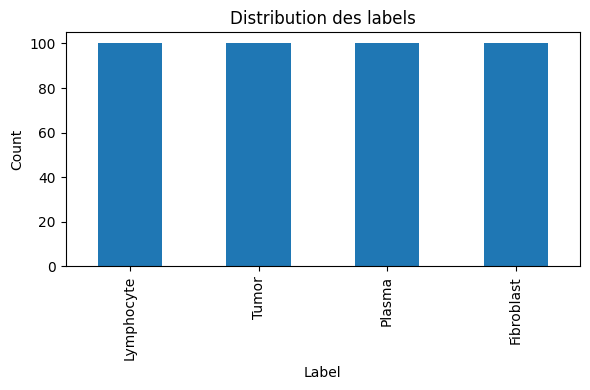

Imbalance ratio (max/min): 1.00


In [44]:
# loading of the CSV
train_df = pd.read_csv(TRAIN_CSV)

# global informations
num_samples = len(train_df)
label_names = sorted(train_df['Label'].unique())
label_counts = train_df['Label'].value_counts()

print(f'Total samples: {num_samples}')
print(f'Labels: {label_names}')

# label distribution plot
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar')
plt.title('Distribution des labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution.png'))
plt.show()

# balance ratio
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# quality control dir
os.makedirs(QUALITY_DIR, exist_ok=True)
for label in label_names:
    os.makedirs(os.path.join(QUALITY_DIR, str(label)),
                exist_ok=True)

def find_image_path(img_id, img_dir):
    #return the path for an existing file
    exts = ['.png', '.jpg', '.jpeg'] 
    for ext in exts:
        cand = os.path.join(img_dir, f'{img_id}{ext}')
        if os.path.exists(cand):
            return cand
    return None

# copy image per label
for _, row in train_df.iterrows():
    img_id = row['Image']
    label = row['Label']
    src_path = find_image_path(img_id, TRAIN_IMG_DIR)
    
    if src_path is None:
        continue
        
    dst_path = os.path.join(QUALITY_DIR, str(label), os.path.basename(src_path))
    
    if not os.path.exists(dst_path):
        shutil.copyfile(src_path, dst_path)


We can see first that there is 4 different labels: Fibroblast, lymphocyte, Plasma and Tumor. Those 4 labels has the exact same amount each, meaning that each class are perfectly balanced, moreover there is 400 total samples, which make this dataset really good for machine learning. It leaves enough images for both the training set and the testing set.
We chose not to remove pictures as there will be potentially similar one in the final dataset. 


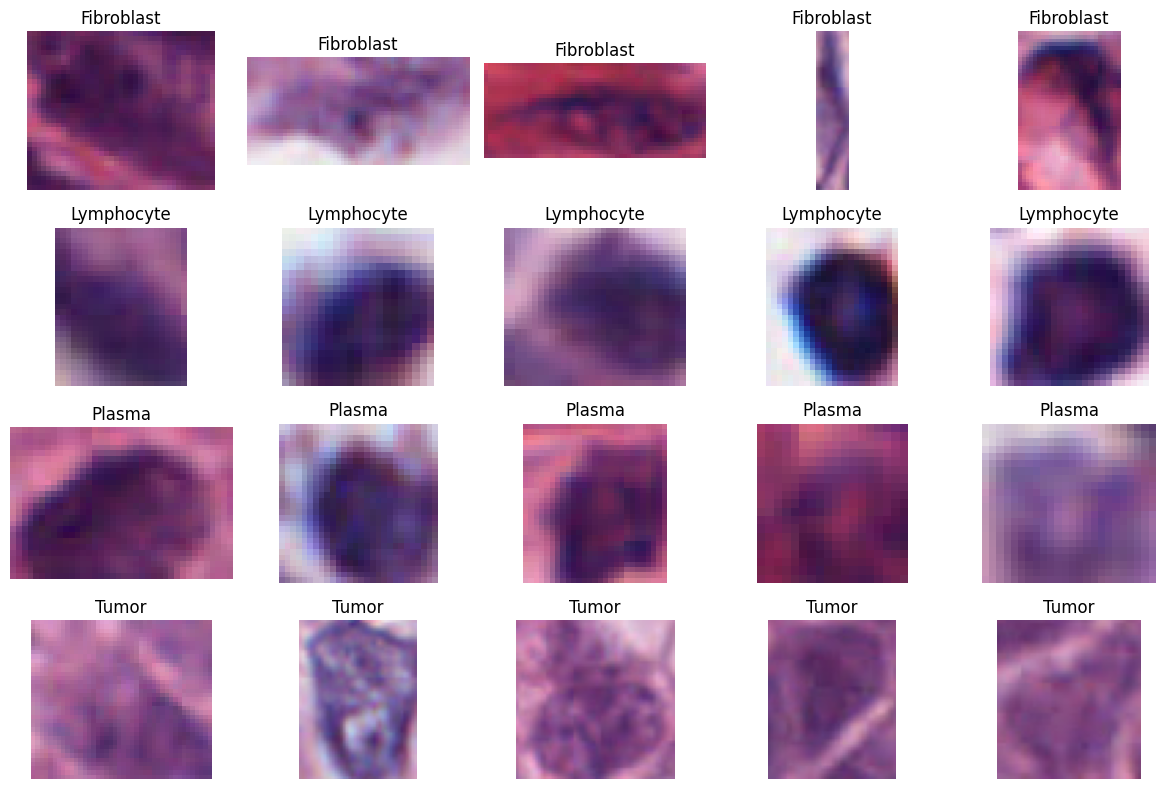

In [45]:
# exemple of each class

#prepare the random seed and the subplot space
np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(len(label_names),
                         N_EXAMPLES_PER_CLASS,
                         figsize=(12, 2 * len(label_names)))


#
for i, label in enumerate(label_names):
    subset = train_df[train_df['Label'] == label]
    sample_rows = subset.sample(
        n=min(N_EXAMPLES_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE
    )
    
    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = find_image_path(row['Image'],
                                  TRAIN_IMG_DIR)
        ax = axes[i, j] if len(label_names) > 1 else axes[j]
        ax.axis('off')
        if img_path is None:
            ax.set_title('Missing')
            continue

        img = io.imread(img_path)
        
        if img.ndim == 2:
            img = color.gray2rgb(img)
        
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        
        ax.imshow(img)
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'examples_grid.png'))
plt.show()


From a first glance, we can see few differences between the classes and already imagines which ones will be harder or easier to classify. For instance, the Lymphocyte is long and has a really distinctive shape compared to the other types which are really round such as the lymphocytes and the plasma. We cal also see that lymphocytes are especially dark, but some look simirlar to some pictures of plasma. However their colors do are a bit different, lyphocyte are more blue, where the plasma seems to have some tints of red and blue, and more variation in color within the plasma. The Tumor's seems bigger than the others with a different texture in it. I can also see that the tumor seems to have a different texture than the others. Finally, 

Through this first analyse, I predict that firbroblast and tumors will be the easiest to predict, wherease Plasma and lymphocyte whom can be similar will be harder.

## Part II/ feature extraction

From the last analysis, i saw multiple different features that seems relevent. 
- Area features: area ratio of the detected cell/tissue region.
- Shape features: eccentricity, compactness, or aspect ratio.
- Intensity features: mean grayscale intensity and dark pixel ratio.
- Color features: mean red intensity and mean blue intensity.
- Texture features: texture contrast descriptor (saw in computer vision class).
- Perimeter feature: perimeter of the detected cell/tissue region.

  

In [46]:
#load the image and preserve the colors
def load_rgb_image(path):
    img = io.imread(path)
    if img.ndim == 2:
        img = color.gray2rgb(img)
    if img.dtype != np.uint8:
        img = util.img_as_ubyte(img)
    return img

#transform the colored image into a 1 channel grayscale one
def grayscale_image(rgb):
    return color.rgb2gray(rgb)

#apply otsu thresholding
def tissue_mask(rgb):
    gray = grayscale_image(rgb)
    threshold = filters.threshold_otsu(gray)
    mask = gray < threshold
    ratio = mask.mean()
    if ratio < 0.01 or ratio > 0.95:
        mask = gray < np.percentile(gray, 90)

    #remove holes and smalls objects for better definition of the main object
    mask = morphology.remove_small_objects(mask, min_size=16)
    mask = morphology.remove_small_holes(mask, area_threshold=16)
    return mask

#get the biggest label region (connected 8 region)  
def _safe_region(mask):
    label_img = measure.label(mask)
    regions = measure.regionprops(label_img)
    if not regions:
        return None
    return max(regions, key=lambda region: region.area)


### Area, shape and perimeter features

This function return multiple features from the biggest label of the mask.
First, there is the area ratio which look at how much of the image does the cell take.
Secondly, there is the eccentricity which show how long is the shape, which is especially good to find the fitoblast from what we analysed earlier.
the bbox aspect ratio show how the witdh is compare to the height, so in other word, a ratio of 1 would mean that its a perfect square or circle, whereas a ratio close to 0 would mean that it is closer to a string. 
The compactness shows how close to a circle the shape is, a 1 would be a perfect circle, whereas a ratio closer to 0 would mean a really stringy or weird shape. From my former analysis, i think this would be a really good way to discriminate both fibroblast which are long and the tumors who are less stringy shaped, but are not almost perfect circles such as lymphocites and plasma.
Finally the perimeter ratio shows the ratio of the contour of a shape compared to the number of pixel in this shape. Therefore, the stranger and long the shape will be, the higher this ratio will be.



In [47]:
#use a descriptor for the texture of the area
def area_features(mask):
    area_ratio = float(mask.mean())
    label_img = measure.label(mask)
    n_components = int(label_img.max())

    return {'area_ratio': area_ratio, 'background_ratio': float(1.0 - area_ratio), 'n_components': float(n_components),}


def area_shape_perimeter_features(mask):
    """Compute handmade area, shape and perimeter descriptors."""
    height, width = mask.shape
    total_pixels = height * width
    main = largest_component_np(mask)
    inside_the_region_pixels = int(main.sum())
    eps = 1e-8 #to not multiple with 0 

    coords = np.column_stack(np.nonzero(main))
    rows = coords[:, 0]
    cols = coords[:, 1]
    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()

    centroid_y = float(rows.mean() / max(height - 1, 1))
    centroid_x = float(cols.mean() / max(width - 1, 1))

    if len(coords) >= 2:
        centered = coords.astype(np.float64) - coords.mean(axis=0)
        cov = np.cov(centered.T) + eps * np.eye(2)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.maximum(eigvals, eps)
        eccentricity = np.sqrt(1.0 - eigvals.min() / eigvals.max())
    else:
        eccentricity = 0.0

    perimeter = perimeter_np(main)
    area_pixels = int(main.sum())
    compactness = 4.0 * np.pi * area_pixels / ((perimeter + eps) ** 2)

    cy = coords[:, 0].astype(np.float32)
    cx = coords[:, 1].astype(np.float32)
    center_y = coords[:, 0].mean()
    center_x = coords[:, 1].mean()
    radial = np.sqrt((cy - center_y) ** 2 + (cx - center_x) ** 2)
    std_radial = float(np.std(radial))

    
    return {
        "area_ratio": foreground_pixels / total_pixels,
        "perimeter_ratio": perimeter / total_pixels,
        "compactness": float(compactness),
        "eccentricity": float(eccentricity),
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "std_radial": std_radial, 
    }


### Intensity and color features

The patches are H&E-stained, so color statistics are meaningful: hematoxylin
usually appears blue/purple and eosin appears pink. The notebook therefore
keeps grayscale, RGB, HSV, and color-channel contrast features.


In [48]:
#return the values inside the mask or all the value if the mask is empty
def _masked_values(channel, mask):
    if np.any(mask):
        return channel[mask].reshape(-1)
    return channel.reshape(-1)


#get the features based on intensity / colors
def intensity_features(rgb, mask):
    rgb_float = util.img_as_float(rgb) 
    
    gray = grayscale_image(rgb)
    p25, p50, p75 = np.percentile(gray_flat, [25, 50, 75])
    values_gray = _masked_values(gray, mask)
    
    values_r = _masked_values(rgb_float[:, :, 0], mask)
    values_b = _masked_values(rgb_float[:, :, 2], mask)
    blue_red_ratio = np.mean(values_b / (values_r + 1e-6))
    hue_ratio = np.mean(g / (r + b + 1e-6))

    
    return {
        'gray_mean': float(np.mean(values_gray)),
        'gray_std': float(np.std(gray_flat)),
        'gray_p25': float(p25),
        'gray_p50': float(p50),
        'gray_p75': float(p75),
        'red_mean': float(np.mean(values_r)),
        'r_std': float(np.std(r)),
        'blue_mean': float(np.mean(values_b)),
        'b_mean': float(np.mean(b)),
        'blue_red_ratio': float(blue_red_ratio),
        'hue_ratio': float(hue_ratio),
    }


### features visualisation

In [49]:
def extract_features_from_path(img_path):
    """Extract all homemade features from one image."""
    rgb = load_rgb_image(img_path)
    mask = tissue_mask(rgb)

    features_dict = {}
    features_dict.update(area_features(mask))
    features_dict.update(shape_features(mask))
    features_dict.update(intensity_features(rgb, mask))
    features_dict.update(texture_features(rgb, mask))
    return features_dict


def build_feature_table(df, image_dir, include_labels=True):
    """Extract features for all images listed in a dataframe."""
    rows = []
    n_total = len(df)

    for count, (_, row) in enumerate(df.iterrows(), start=1):
        img_id = row['Image']
        img_path = find_image_path(img_id, image_dir)

        if img_path is None:
            print(f'Missing image: {img_id}')
            continue

        try:
            features_row = extract_features_from_path(img_path)
        except Exception as exc:
            print(f'Error with {img_id}: {exc}')
            continue

        features_row['Image'] = img_id
        if include_labels:
            features_row['Label'] = row['Label']
        rows.append(features_row)

        if count % 50 == 0 or count == n_total:
            print(f'Processed {count}/{n_total} images')

    return pd.DataFrame(rows)


features_df = build_feature_table(
    train_df,
    TRAIN_IMG_DIR,
    include_labels=True,
)

features_df.to_csv(FEATURES_TRAIN_CSV, index=False)
print(f'Saved features to: {FEATURES_TRAIN_CSV}')
features_df.head()


Missing image: 0
Missing image: 1
Missing image: 2
Missing image: 3
Missing image: 4
Missing image: 5
Missing image: 6
Missing image: 7
Missing image: 8
Missing image: 9
Error with 10: name 'gray_flat' is not defined
Error with 11: name 'gray_flat' is not defined
Error with 12: name 'gray_flat' is not defined
Error with 13: name 'gray_flat' is not defined
Error with 14: name 'gray_flat' is not defined
Error with 15: name 'gray_flat' is not defined
Error with 16: name 'gray_flat' is not defined
Error with 17: name 'gray_flat' is not defined
Error with 18: name 'gray_flat' is not defined
Error with 19: name 'gray_flat' is not defined
Error with 20: name 'gray_flat' is not defined
Error with 21: name 'gray_flat' is not defined
Error with 22: name 'gray_flat' is not defined
Error with 23: name 'gray_flat' is not defined
Error with 24: name 'gray_flat' is not defined
Error with 25: name 'gray_flat' is not defined
Error with 26: name 'gray_flat' is not defined
Error with 27: name 'gray_flat'

""


**Feature justification summary:**

- `area_ratio`, `background_ratio`, `n_components`: amount and fragmentation
  of tissue in the patch.
- `bbox_aspect_ratio`, `compactness`, `eccentricity`, `extent`, `solidity`:
  shape of the main tissue region.
- `gray_*`, `red_*`, `green_*`, `blue_*`, `hue_mean`, `saturation_mean`:
  intensity and H&E color information.
- `glcm_*`: texture and local gray-level organization.

The feature table is saved to CSV so that training can be restarted without
extracting all features again.


### Feature visualization

Boxplots help identify discriminative features. The correlation matrix helps
spot redundant features. Highly correlated features are not necessarily bad,
but removing some of them can simplify the model and reduce overfitting.


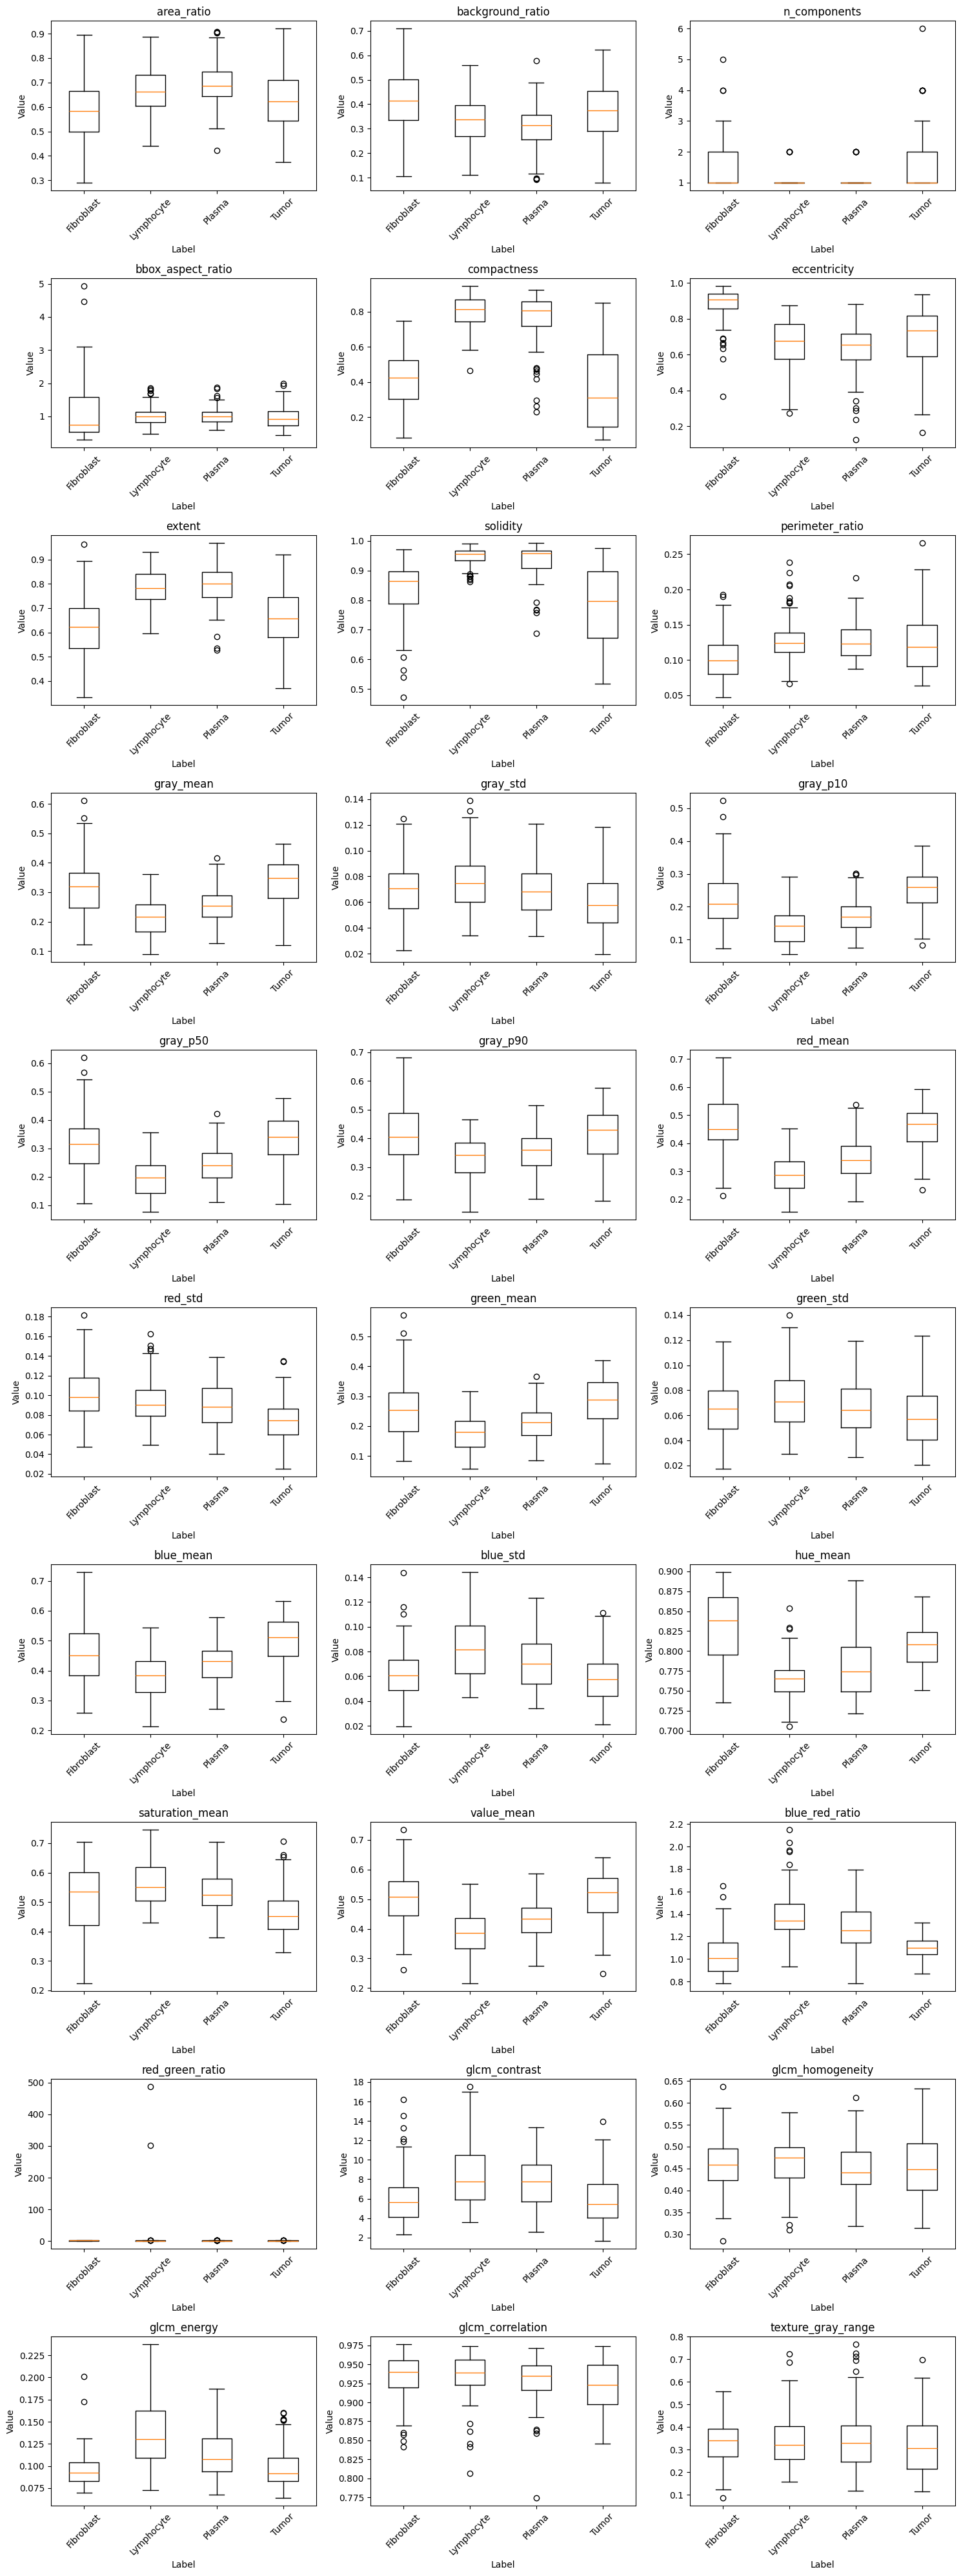

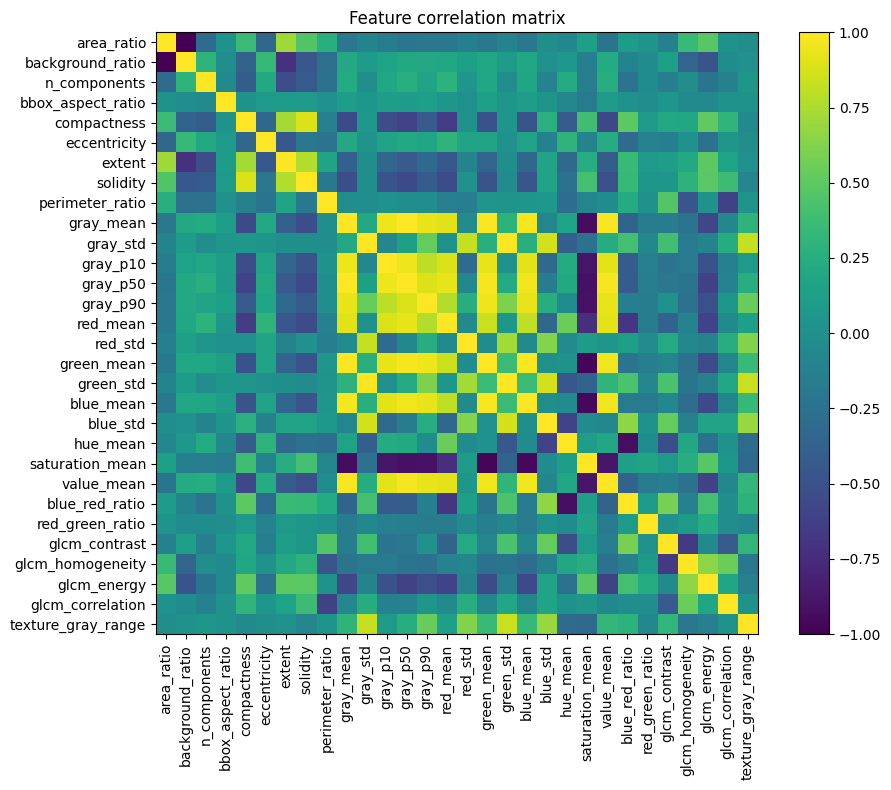

Highly correlated pairs (|r| > 0.90):
area_ratio / background_ratio: -1.000
gray_mean / gray_p10: 0.952
gray_mean / gray_p50: 0.993
gray_mean / gray_p90: 0.933
gray_mean / red_mean: 0.907
gray_mean / green_mean: 0.990
gray_mean / blue_mean: 0.972
gray_mean / saturation_mean: -0.933
gray_mean / value_mean: 0.979
gray_std / green_std: 0.985
gray_p10 / gray_p50: 0.951
gray_p10 / green_mean: 0.932
gray_p10 / blue_mean: 0.915
gray_p10 / value_mean: 0.917
gray_p50 / red_mean: 0.926
gray_p50 / green_mean: 0.975
gray_p50 / blue_mean: 0.955
gray_p50 / saturation_mean: -0.911
gray_p50 / value_mean: 0.974
gray_p90 / green_mean: 0.949
gray_p90 / blue_mean: 0.933
gray_p90 / saturation_mean: -0.901
gray_p90 / value_mean: 0.924
red_mean / value_mean: 0.919
green_mean / blue_mean: 0.983
green_mean / saturation_mean: -0.962
green_mean / value_mean: 0.958
blue_mean / saturation_mean: -0.957
blue_mean / value_mean: 0.956
hue_mean / blue_red_ratio: -0.926


In [33]:
feature_cols = [
    col for col in features_df.columns
    if col not in ['Image', 'Label']
]

# Number of columns in the subplot grid
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.ravel()

for i, feat_name in enumerate(feature_cols):
    data = [
        features_df[features_df['Label'] == lab][feat_name].dropna().values
        for lab in label_names
    ]

    axes[i].boxplot(data, labels=[str(lab) for lab in label_names])
    axes[i].set_title(feat_name)
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot spaces
for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_boxplots_grid.png'))
plt.show()


corr = features_df[feature_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_corr.png'))
plt.show()


high_corr_pairs = []

for i, feat_a in enumerate(feature_cols):
    for feat_b in feature_cols[i + 1:]:
        value = corr.loc[feat_a, feat_b]
        if abs(value) > 0.90:
            high_corr_pairs.append((feat_a, feat_b, value))

print('Highly correlated pairs (|r| > 0.90):')
for feat_a, feat_b, value in high_corr_pairs:
    print(f'{feat_a} / {feat_b}: {value:.3f}')

**Analysis to complete after running:**

- Which boxplots show the clearest separation between labels?
- Which features are almost redundant according to the correlation matrix?
- Are the visual observations from Part I consistent with the numerical
  features?


## Part III — Machine learning training

This part uses `scikit-learn`. The pipeline includes:

1. removal of constant features,
2. imputation of missing values,
3. feature normalization,
4. univariate feature selection,
5. hyperparameter tuning by grid search,
6. stratified cross-validation.

The project asks for at least two classification algorithms studied during the
course. Here we compare:

- **Logistic Regression** with the `lbfgs` solver,
- **SGDClassifier**, optimized with stochastic gradient descent,
- **K-Nearest Neighbors**, a classical supervised classification baseline.


In [34]:
ml_df = pd.read_csv(FEATURES_TRAIN_CSV).dropna(subset=["Label"])

selected_feature_cols = [
    "area_ratio",
    "main_area_ratio",
    "perimeter_ratio",
    "compactness",
    "eccentricity",
    "bbox_aspect_ratio",
    "bbox_extent",
    "gray_mean",
    "gray_std",
    "dark_pixel_ratio",
    "red_mean",
    "green_mean",
    "blue_mean",
    "red_std",
    "blue_std",
    "blue_red_ratio",
    "texture_contrast",
]

missing_features = [
    col for col in selected_feature_cols
    if col not in ml_df.columns
]
if len(missing_features) > 0:
    raise ValueError(f"Missing selected features: {missing_features}")

feature_cols = selected_feature_cols
X = ml_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = ml_df["Label"].values

n_features = len(feature_cols)
candidate_k_values = [8, 11, 14, n_features]
k_values = sorted(set(k for k in candidate_k_values if k <= n_features))

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
]

scoring_metric = "f1_weighted"
model_results = []
trained_searches = {}


def evaluate_predictions(model_name, y_true, y_pred, best_score, best_params):
    """Return the requested classification metrics."""
    return {
        "model": model_name,
        "best_cv_f1_weighted": float(best_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "best_params": best_params,
    }


def run_grid_model(model_name, classifier, param_grid):
    """Tune a model with GridSearchCV, then report CV predictions."""
    pipeline = Pipeline(base_steps + [("clf", classifier)])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring_metric,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X, y)

    # Cross-validated predictions using the best tuned pipeline.
    # This keeps the preprocessing inside each fold.
    preds = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv,
        n_jobs=-1,
    )

    result = evaluate_predictions(
        model_name=model_name,
        y_true=y,
        y_pred=preds,
        best_score=search.best_score_,
        best_params=search.best_params_,
    )

    cm = confusion_matrix(y, preds, labels=label_names)
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )
    display_obj.plot(xticks_rotation=30)
    plt.title(f"Cross-validated confusion matrix: {model_name}")
    plt.tight_layout()
    fig_name = f"confusion_matrix_{model_name}.png"
    plt.savefig(os.path.join(FIG_DIR, fig_name))
    plt.show()

    return result, search


print("Selected features used for machine learning:")
for feature in feature_cols:
    print("-", feature)

print("\nNumber of selected features:", n_features)
print("Feature-selection k values tested:", k_values)

EmptyDataError: No columns to parse from file

### SVM

In [ ]:
svm_classifier = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

svm_param_grid = {
    "select__k": k_values,
    "clf__C": [0.1, 1.0, 10.0, 100.0],
    "clf__gamma": ["scale", 0.01, 0.1, 1.0],
}

svm_result, svm_search = run_grid_model(
    "SVM_RBF",
    svm_classifier,
    svm_param_grid,
)

model_results.append(svm_result)
trained_searches["SVM_RBF"] = svm_search
display(pd.DataFrame([svm_result]))

### Random Forest


In [35]:
rf_classifier = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_param_grid = {
    "select__k": k_values,
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 4, 8, 12],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", None],
}

rf_result, rf_search = run_grid_model(
    "RandomForest",
    rf_classifier,
    rf_param_grid,
)

model_results.append(rf_result)
trained_searches["RandomForest"] = rf_search
display(pd.DataFrame([rf_result]))

NameError: name 'RandomForestClassifier' is not defined

### KNN

In [36]:
knn_classifier = KNeighborsClassifier()

knn_param_grid = {
    "select__k": k_values,
    "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

knn_result, knn_search = run_grid_model(
    "KNN",
    knn_classifier,
    knn_param_grid,
)

model_results.append(knn_result)
trained_searches["KNN"] = knn_search
display(pd.DataFrame([knn_result]))

NameError: name 'k_values' is not defined

### logistic regression with L-BFGS

In [37]:
logreg_classifier = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
    solver="lbfgs",
)

logreg_param_grid = {
    "select__k": k_values,
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

logreg_result, logreg_search = run_grid_model(
    "LogisticRegression_LBFGS",
    logreg_classifier,
    logreg_param_grid,
)

model_results.append(logreg_result)
trained_searches["LogisticRegression_LBFGS"] = logreg_search
display(pd.DataFrame([logreg_result]))

NameError: name 'k_values' is not defined

## Part IV — Prediction on the future test set

This code is ready for the test phase. When the test image folder becomes
available, it extracts the same features, applies the selected model, and saves
`test.csv` with the same column structure as `train.csv`: `Image`, `Label`.


In [ ]:
def make_test_dataframe(test_img_dir):
    """Create a dataframe containing test image identifiers."""
    image_files = [
        file_name for file_name in os.listdir(test_img_dir)
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    image_files = sorted(image_files)
    image_ids = [os.path.splitext(file_name)[0] for file_name in image_files]
    return pd.DataFrame({'Image': image_ids})


def predict_test_set(test_img_dir, output_csv):
    """Extract test features and save predicted labels."""
    if not os.path.exists(test_img_dir):
        print('Test directory not found. No prediction file was created.')
        return None

    saved = joblib.load(MODEL_PATH)
    trained_model = saved['model']
    saved_feature_cols = saved['feature_cols']

    test_df = make_test_dataframe(test_img_dir)
    test_features_df = build_feature_table(
        test_df,
        test_img_dir,
        include_labels=False,
    )

    for col in saved_feature_cols:
        if col not in test_features_df.columns:
            test_features_df[col] = 0.0

    X_test = test_features_df[saved_feature_cols].values
    predictions = trained_model.predict(X_test)

    output_df = pd.DataFrame({
        'Image': test_features_df['Image'].values,
        'Label': predictions,
    })
    output_df.to_csv(output_csv, index=False)
    print(f'Saved predictions to: {output_csv}')
    return output_df


TEST_OUTPUT_CSV = os.path.join(DATA_DIR, 'test.csv')

if os.path.exists(TEST_IMG_DIR):
    test_predictions = predict_test_set(TEST_IMG_DIR, TEST_OUTPUT_CSV)
else:
    print('Test image folder is not available yet.')


## Final checklist before submission

- Restart the kernel and run all cells.
- Check that no error message remains.
- Complete the short written analyses after the figures.
- Verify that `features_train.csv`, `best_model.joblib`, and `test.csv` are
  created when the corresponding folders exist.
- Keep the notebook filename simple, with no spaces or special characters.
